<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/hellchar--letter-tm-visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data

In [1]:
#@title Load the data
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip

In [2]:
#@title Load the model weights
!wget https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth

--2025-09-10 15:56:28--  https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ipavlopoulos/greek-letter-vision/refs/heads/main/best_cnn_letter_model.pth [following]
--2025-09-10 15:56:28--  https://raw.githubusercontent.com/ipavlopoulos/greek-letter-vision/refs/heads/main/best_cnn_letter_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17203749 (16M) [application/octet-stream]
Saving to: ‘best_cnn_letter_model.pth’

best_cnn_letter_mod 100%[===================>]  16.41M  91.3MB/s    in 0.2s    


In [3]:
#@title Get the metadata
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])
metadata = pd.read_csv('metadata.csv')
data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [14]:
#@title Dataset development
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

class RandomLacunae(object):
    """
    Apply lacunae-like erasures to simulate missing text regions (irregular blobs).
    """
    def __init__(self, num_lacunae=(1, 4), size_range=(0.02, 0.15), p=0.5, v=0.5):
        """
        Args:
            num_lacunae (tuple): min/max number of lacunae per image
            size_range (tuple): relative size range (as fraction of image area)
            p (float): probability of applying the augmentation
        """
        self.num_lacunae = num_lacunae
        self.size_range = size_range
        self.p = p
        self.v = v

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img).copy()
        h, w = img_np.shape[:2]

        for _ in range(random.randint(*self.num_lacunae)):
            # Random size relative to image
            lacuna_area = random.uniform(*self.size_range) * h * w
            lacuna_w = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))
            lacuna_h = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))

            # Random center
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)

            # Create irregular blob mask using cv2 ellipse + random contour distortion
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(mask, (x, y), (lacuna_w//2, lacuna_h//2),
                        angle=random.randint(0, 180),
                        startAngle=0, endAngle=360,
                        color=1, thickness=-1)

            # Optionally: erode/dilate with noise to add irregularity
            if random.random() < 0.7:
                kernel_size = random.choice([3,5,7])
                kernel = np.ones((kernel_size,kernel_size), np.uint8)
                if random.random() < 0.5:
                    mask = cv2.erode(mask, kernel, iterations=1)
                else:
                    mask = cv2.dilate(mask, kernel, iterations=1)

            # Apply lacuna (set pixels to background = white/255)
            img_np[mask == 1] = 255 * self.v  # assuming grayscale / white parchment

        return torch.tensor(img_np) if isinstance(img, torch.Tensor) else img_np

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d
y_train_year = data.loc[train_indices_2d].year.to_list()
y_train_tm = data.loc[train_indices_2d].TM.to_list()

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d
y_val_year = data.loc[val_indices_2d].year.to_list()
y_val_tm = data.loc[val_indices_2d].TM.to_list()

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d
y_test_year = data.loc[test_indices_2d].year.to_list()
y_test_tm = data.loc[test_indices_2d].TM.to_list()

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [18]:
#@title Train data - not augmented

class SimpleDataset(Dataset):
    def __init__(self, X, y=None, year=None, TM=None):
        self.X = X
        self.y = y
        self.year = year
        self.TM = TM # Add TM attribute

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        # Apply only the test_transform (ToTensor and Normalize)
        if test_transform:
             image = test_transform(image)

        if self.y is not None:
            if self.year is not None:
                if self.TM is not None:
                    return image, self.y[idx], self.year[idx], self.TM[idx]
                else:
                    return image, self.y[idx], self.year[idx]
            else:
                return image, self.y[idx]
        else:
            return image

train_dataset_no_aug = SimpleDataset(image_data_2d[train_indices_2d], y_train_encoded_2d, y_train_year, y_train_tm)
test_dataset_no_aug = SimpleDataset(image_data_2d[test_indices_2d], y_test_encoded_2d, y_test_year, y_test_tm)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size)
test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=batch_size)

In [6]:
#@title Source (algorithm)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

def evaluate(model, test_loader, device, label_encoder):
    model.eval()
    correct = 0
    total = 0
    pred, gold = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pred.extend(predicted.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    # Inverse transform the encoded predicted and true labels to get original letter names
    pred = label_encoder.inverse_transform(pred)
    gold = label_encoder.inverse_transform(gold)

    # Display classification report
    print(classification_report(gold, pred, zero_division=0))

    # Display confusion matrix
    cm_2d = confusion_matrix(gold, pred, labels=label_encoder.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
    plt.show()

# TTA/augmentation for embeddings
tta_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(size=(64,64), scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

In [7]:
#@title Load the model
model = CNN2D(num_classes=len(label_encoder.classes_), image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('best_cnn_letter_model.pth', map_location=torch.device(device)))
#evaluate(model, test_loader_2d, device, label_encoder)

<All keys matched successfully>

In [19]:
#@title Extract the embeddings
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []
    years = [] # Add a list to store years
    TM_list = [] # Use a different name to avoid conflict with TM variable

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                # Handle batches with 2 or 3 or 4 items
                if len(batch) == 4:
                    images, targets, batch_years, batch_tm = batch
                    labels.extend(targets.numpy())
                    years.extend(batch_years) # Store years
                    TM_list.extend(batch_tm) # Store TM
                elif len(batch) == 3:
                    images, targets, batch_years = batch
                    labels.extend(targets.numpy())
                    years.extend(batch_years) # Store years
                    TM_list.extend([None] * len(targets)) # Add None for TM if not present
                elif len(batch) == 2:
                    images, targets = batch
                    labels.extend(targets.numpy())
                    years.extend([None] * len(targets)) # Add None for years if not present
                    TM_list.extend([None] * len(targets)) # Add None for TM if not present
                else:
                    images = batch
                    targets = None
                    years.extend([None] * len(images)) # Add None for years if not present
                    TM_list.extend([None] * len(images)) # Add None for TM if not present


            images = images.to(device)
            emb = model.get_embeddings(images)  # (batch_size, 512)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    if labels:
        labels = np.array(labels)
        if any(years) and any(TM_list): # Only return years and TM if at least one is not None
            years = np.array(years)
            TM_list = np.array(TM_list)
            return embeddings, labels, years, TM_list
        elif any(years):
            years = np.array(years)
            return embeddings, labels, years
        elif any(TM_list):
             TM_list = np.array(TM_list)
             return embeddings, labels, None, TM_list
        else:
            return embeddings, labels # Return only embeddings and labels if no years or TM
    else:
        return embeddings

# Extract embeddings
#train_embeddings, train_labels = extract_embeddings(model, train_loader_2d_aug, device)
train_embeddings_no_aug, train_labels_no_aug, train_years_no_aug, train_tm_no_aug = extract_embeddings(model, train_loader_no_aug, device)
test_embeddings, test_labels, test_years, test_tm = extract_embeddings(model, test_loader_no_aug, device)

# Visualise time-letter forms

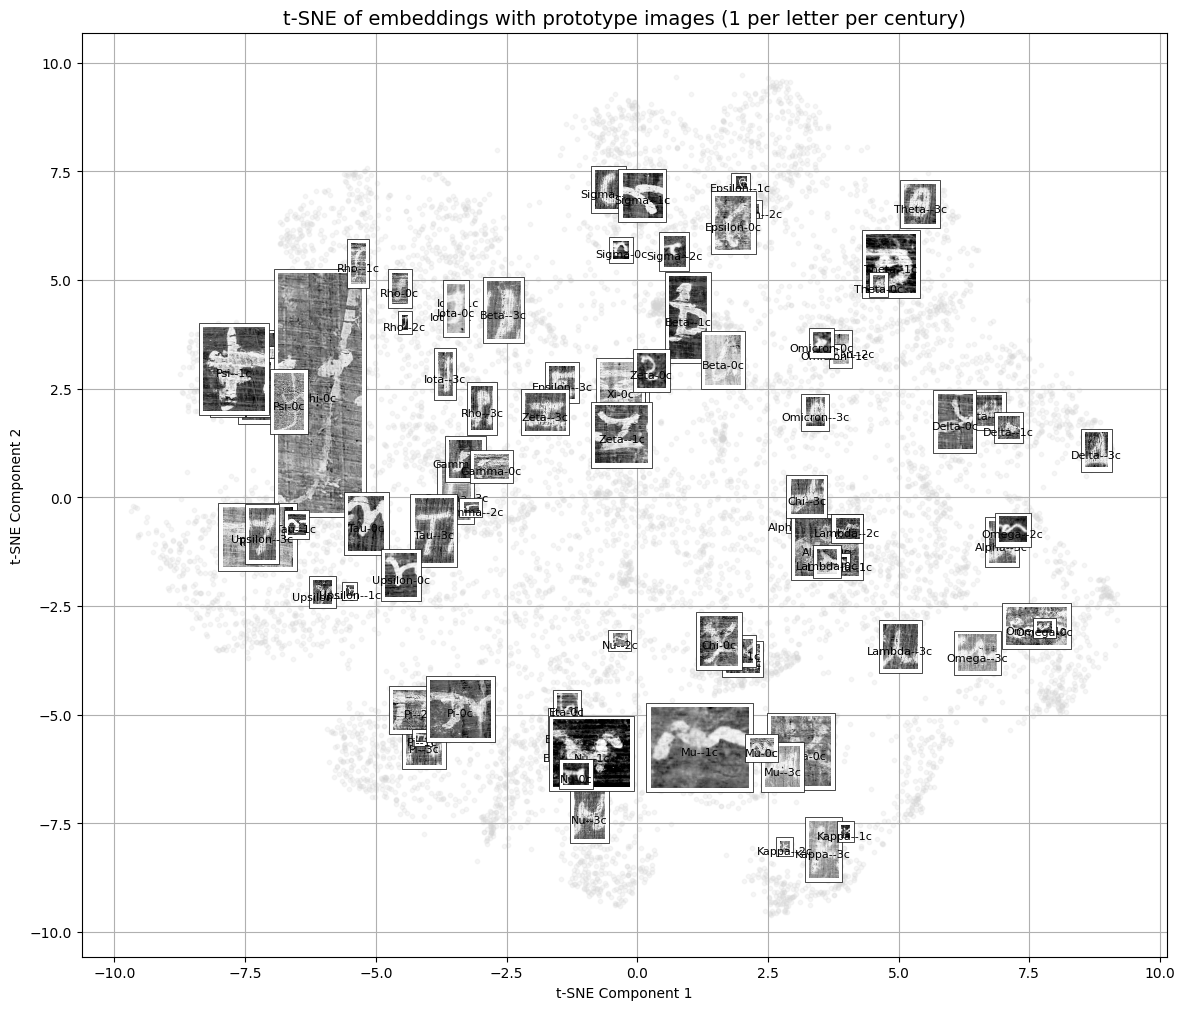

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# --- Prepare embeddings for t-SNE ---
embeddings_array = train_embeddings_no_aug.reshape(train_embeddings_no_aug.shape[0], -1)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
tsne_components = tsne.fit_transform(embeddings_array)

# --- Build DataFrame with metadata ---
tsne_df = pd.DataFrame(tsne_components, columns=['tsne_component_1', 'tsne_component_2'])
tsne_df['letter'] = train_labels_no_aug
tsne_df['year'] = train_years_no_aug
tsne_df['century'] = (train_years_no_aug // 100 + 1).astype(int)   # convert year to century (e.g., 700 → 8th)

# Add image paths to the DataFrame
image_folder = 'Timeline20250531/cliplets/'
tsne_df['img_path'] = data.loc[train_indices_2d]['filename'].values
tsne_df['img_path'] = image_folder + tsne_df['img_path'] # Construct the full path


# --- Function to load images ---
def get_image(path, zoom=0.4):
    img = Image.open(path).convert("L")
    #img = plt.imread(path)
    return OffsetImage(img, zoom=zoom, cmap="Greys")

# --- Plot t-SNE ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.scatter(tsne_df['tsne_component_1'], tsne_df['tsne_component_2'],
           c='lightgray', alpha=0.2, s=10)  # background all points

# --- For each (letter, century), choose prototype ---
for (letter, century), group in tsne_df.groupby(['letter', 'century']):
    # centroid of the group
    centroid = group[['tsne_component_1', 'tsne_component_2']].mean().values
    # find the closest point to centroid
    dists = np.linalg.norm(group[['tsne_component_1', 'tsne_component_2']].values - centroid, axis=1)
    idx = dists.argmin()
    row = group.iloc[idx]

    # overlay the image
    ab = AnnotationBbox(get_image(row['img_path'], zoom=0.35),
                        (row['tsne_component_1'], row['tsne_component_2']),
                        frameon=True, pad=0.3, bboxprops=dict(edgecolor='black', linewidth=0.5))
    ax.add_artist(ab)
    ax.text(row['tsne_component_1'], row['tsne_component_2'],
            f"{label_encoder.inverse_transform([int(letter)])[0]}-{century}c", fontsize=8, ha="center", va="top")


ax.set_title("t-SNE of embeddings with prototype images (1 per letter per century)", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

# Visualise TM-letter forms

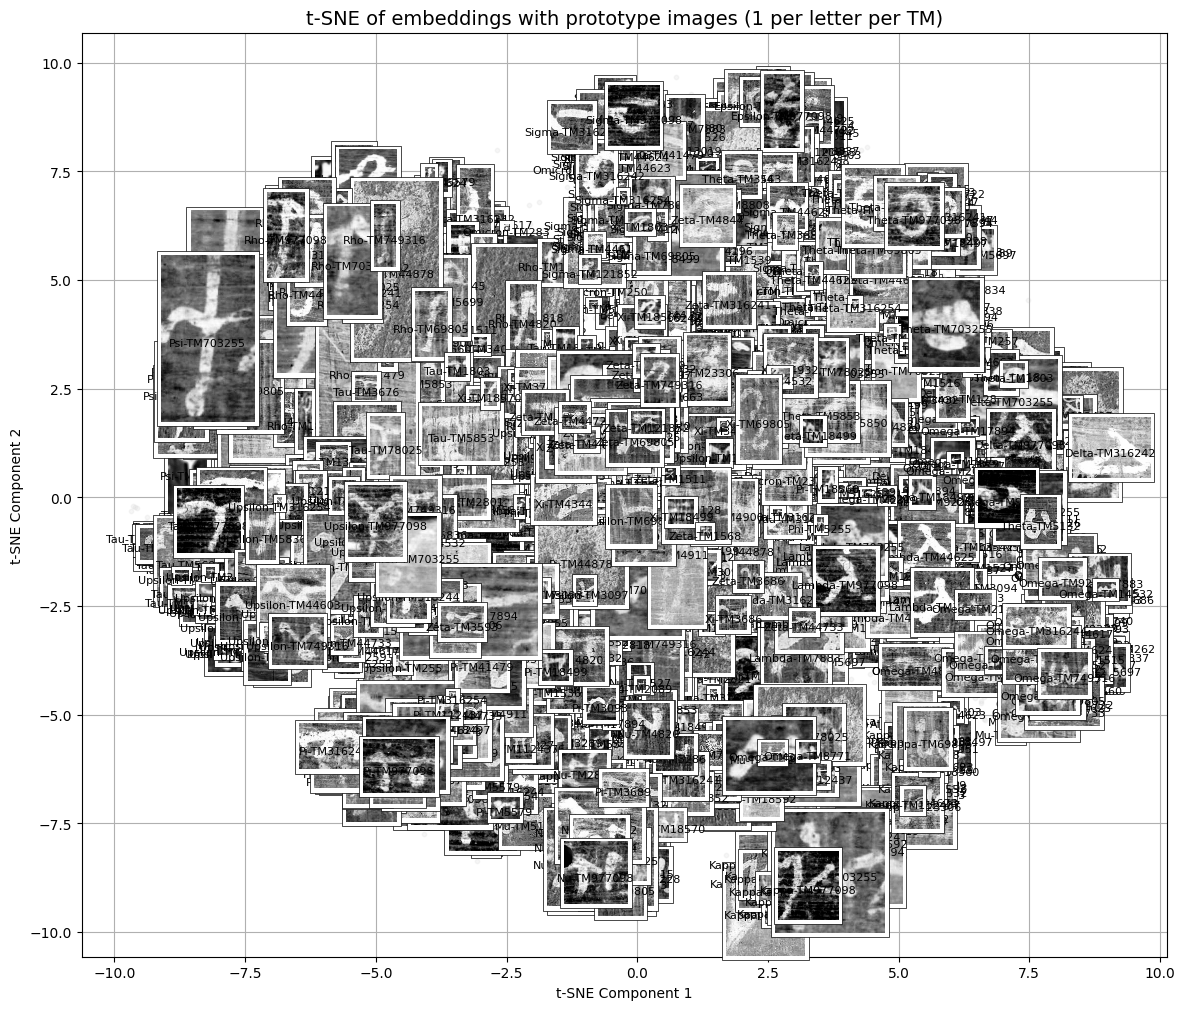

In [21]:
# --- Build DataFrame with metadata including TM ---
tsne_df_tm = pd.DataFrame(tsne_components, columns=['tsne_component_1', 'tsne_component_2'])
tsne_df_tm['letter'] = train_labels_no_aug
tsne_df_tm['TM'] = train_tm_no_aug # Add TM
tsne_df_tm['year'] = train_years_no_aug # Keep year for context if needed
tsne_df_tm['century'] = (train_years_no_aug // 100 + 1).astype(int)

# Add image paths to the DataFrame
image_folder = 'Timeline20250531/cliplets/'
tsne_df_tm['img_path'] = data.loc[train_indices_2d]['filename'].values
tsne_df_tm['img_path'] = image_folder + tsne_df_tm['img_path'] # Construct the full path


# --- Plot t-SNE with TM as grouping variable ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.scatter(tsne_df_tm['tsne_component_1'], tsne_df_tm['tsne_component_2'],
           c='lightgray', alpha=0.2, s=10)  # background all points

# --- For each (letter, TM), choose prototype ---
# Group by letter and TM
for (letter, tm), group in tsne_df_tm.groupby(['letter', 'TM']):
    # centroid of the group
    centroid = group[['tsne_component_1', 'tsne_component_2']].mean().values
    # find the closest point to centroid
    dists = np.linalg.norm(group[['tsne_component_1', 'tsne_component_2']].values - centroid, axis=1)
    idx = dists.argmin()
    row = group.iloc[idx]

    # overlay the image
    ab = AnnotationBbox(get_image(row['img_path'], zoom=0.35),
                        (row['tsne_component_1'], row['tsne_component_2']),
                        frameon=True, pad=0.3, bboxprops=dict(edgecolor='black', linewidth=0.5))
    ax.add_artist(ab)

    # Add text label with letter and TM
    ax.text(row['tsne_component_1'], row['tsne_component_2'],
            f"{label_encoder.inverse_transform([int(letter)])[0]}-TM{tm}", fontsize=8, ha="center", va="top")


ax.set_title("t-SNE of embeddings with prototype images (1 per letter per TM)", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

# Visualisation of Alpha per TM

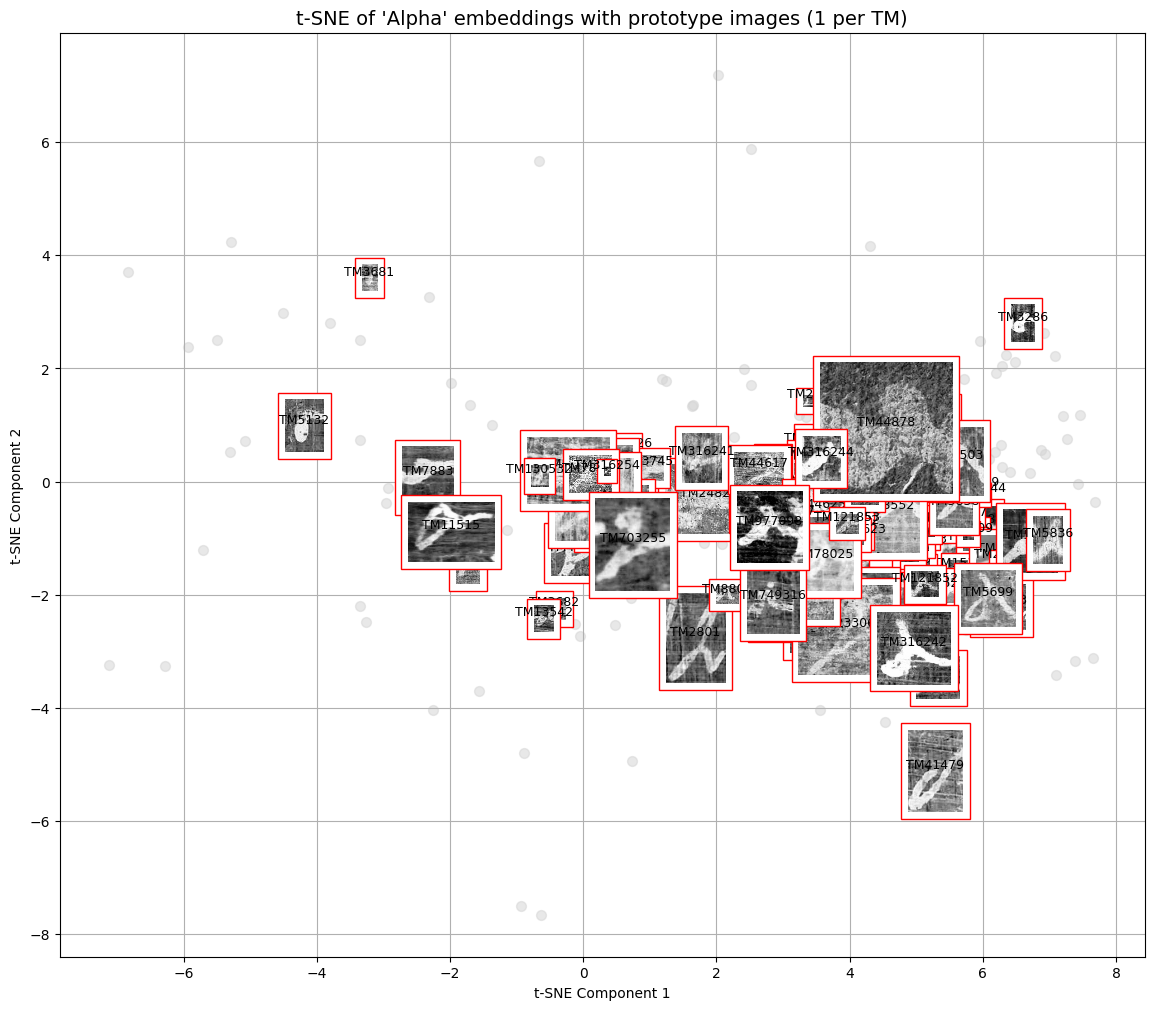

In [23]:
# Filter data for 'Alpha'
alpha_tsne_df = tsne_df_tm[tsne_df_tm['letter'] == label_encoder.transform(['Alpha'])[0]].copy()

# --- Plot t-SNE for Alpha, with one prototype image per TM ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.scatter(alpha_tsne_df['tsne_component_1'], alpha_tsne_df['tsne_component_2'],
           c='lightgray', alpha=0.5, s=50)  # background all Alpha points

# --- For each unique TM of Alpha, choose prototype ---
for tm, group in alpha_tsne_df.groupby('TM'):
    # centroid of the group
    centroid = group[['tsne_component_1', 'tsne_component_2']].mean().values
    # find the closest point to centroid
    dists = np.linalg.norm(group[['tsne_component_1', 'tsne_component_2']].values - centroid, axis=1)
    idx = dists.argmin()
    row = group.iloc[idx]

    # overlay the image
    ab = AnnotationBbox(get_image(row['img_path'], zoom=0.4),
                        (row['tsne_component_1'], row['tsne_component_2']),
                        frameon=True, pad=0.5, bboxprops=dict(edgecolor='red', linewidth=1)) # Highlight Alpha prototypes
    ax.add_artist(ab)

    # Add text label with TM
    ax.text(row['tsne_component_1'], row['tsne_component_2'],
            f"TM{tm}", fontsize=9, ha="center", va="bottom")


ax.set_title("t-SNE of 'Alpha' embeddings with prototype images (1 per TM)", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

In [28]:
alpha_tsne_df.TM.value_counts()

,count
TM,
3415,5
663,5
121853,5
316241,5
316244,5
...,...
13542,1
44878,1
5553,1


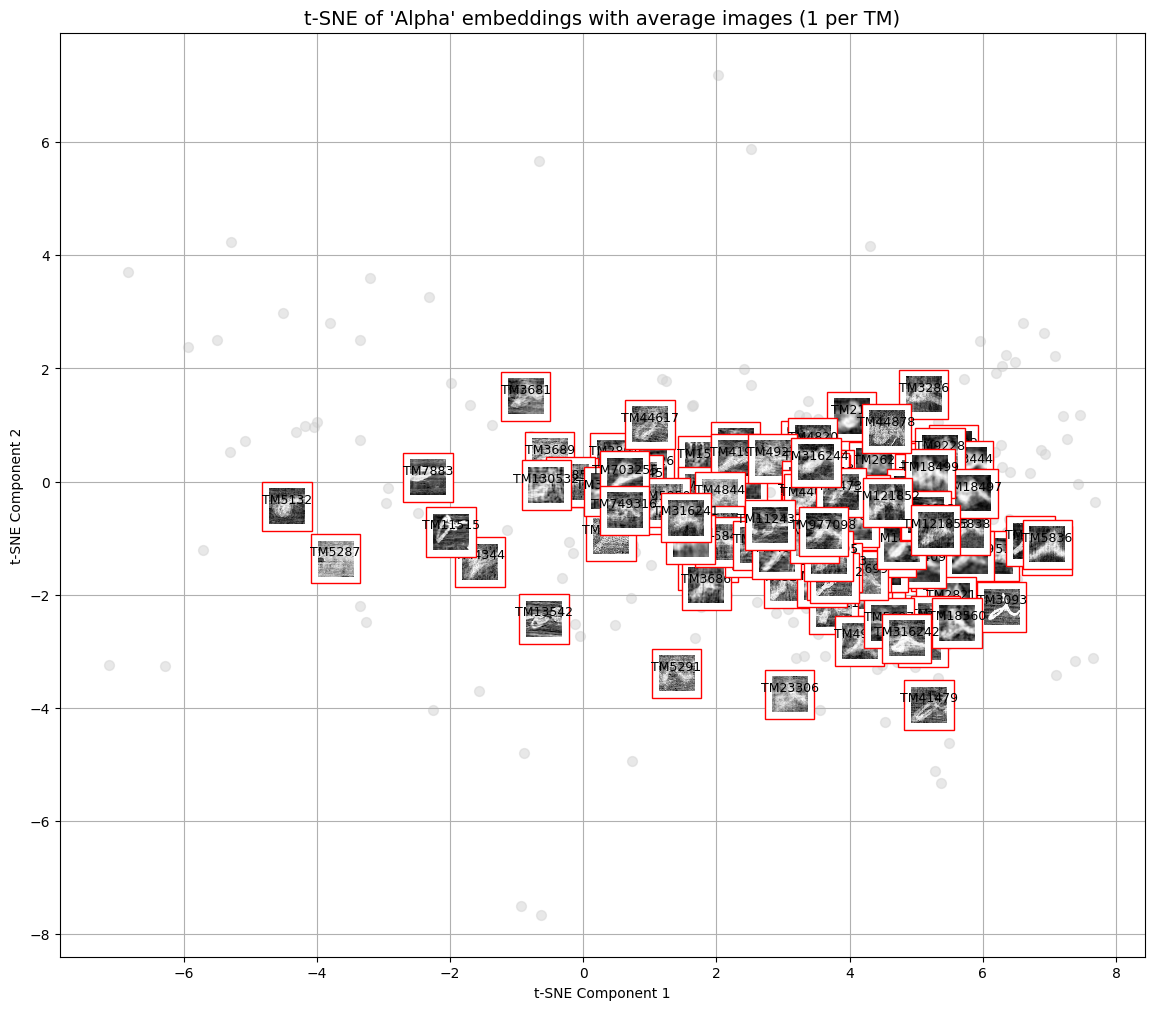

In [31]:
# Filter data for 'Alpha'
alpha_tsne_df = tsne_df_tm[tsne_df_tm['letter'] == label_encoder.transform(['Alpha'])[0]].copy()

# --- Function to get the average image for a group ---
def get_average_image(group_df, size=(64, 64), zoom=0.4):
    # Load all images in the group and resize
    images = []
    for img_path in group_df['img_path']:
        img = Image.open(img_path).convert("L")
        img_resized = img.resize(size, Image.Resampling.LANCZOS) # Use LANCZOS for resizing
        img_np = np.array(img_resized).astype(np.float32) # Convert to float for averaging
        images.append(img_np)

    if not images:
        return None

    # Calculate the average image
    average_img_np = np.mean(images, axis=0)

    # Convert back to uint8 for displaying
    average_img_pil = Image.fromarray(average_img_np.astype(np.uint8))

    return OffsetImage(average_img_pil, zoom=zoom, cmap="Greys")


# --- Plot t-SNE for Alpha, with average image per TM ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.scatter(alpha_tsne_df['tsne_component_1'], alpha_tsne_df['tsne_component_2'],
           c='lightgray', alpha=0.5, s=50)  # background all Alpha points

# --- For each unique TM of Alpha, display the average image ---
for tm, group in alpha_tsne_df.groupby('TM'):
    if len(group) > 0: # Ensure the group is not empty
        # centroid of the group (for image placement)
        centroid = group[['tsne_component_1', 'tsne_component_2']].mean().values

        # Get the average image for the group
        avg_image_box = get_average_image(group, zoom=0.4)

        if avg_image_box:
            # overlay the average image
            ab = AnnotationBbox(avg_image_box,
                                (centroid[0], centroid[1]), # Place at centroid
                                frameon=True, pad=0.5, bboxprops=dict(edgecolor='red', linewidth=1)) # Highlight Alpha prototypes
            ax.add_artist(ab)

            # Add text label with TM
            ax.text(centroid[0], centroid[1],
                    f"TM{tm}", fontsize=9, ha="center", va="bottom")


ax.set_title("t-SNE of 'Alpha' embeddings with average images (1 per TM)", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()